# Линейная регрессия и МНК

## Генерация искусственных данных: зависимость цены квартиры от её площади

В этом блоке мы создаём искусственные данные, моделирующие зависимость цены квартиры от её площади. Для генерации используем линейную модель с добавлением случайного шума: цена = (стоимость за кв.м) × (площадь) + базовая цена + случайный шум.

In [30]:
import numpy as np

# Для воспроизводимости результатов
np.random.seed(42)

# Генерируем 100 случайных площадей от 20 до 100 кв.м
X = np.random.uniform(20, 100, size=100)

# "Истинные" параметры зависимости
a_real = 85_000  # руб./кв.м
b_real = 500_000  # базовая цена

# Добавим шум, чтобы симулировать реальные рыночные отклонения
noise = np.random.normal(0, 500_000, size=100)

# Целевая переменная — цена квартиры
y = a_real * X + b_real + noise

`np.seed()` — фиксирует генератор случайных чисел для воспроизводимости.

`np.random.uniform(a, b, size)` — генерирует массив случайных чисел из равномерного распределения на интервале [a, b].

`np.random.normal(loc, scale, size)` — генерирует случайные значения из нормального распределения с заданным средним loc и стандартным отклонением scale.



## Визуализация исходных данных

Теперь визуализируем полученные точки на графике: по оси X будет площадь квартиры, по оси Y — её цена. Это даст представление о структуре данных и наличии линейной зависимости.

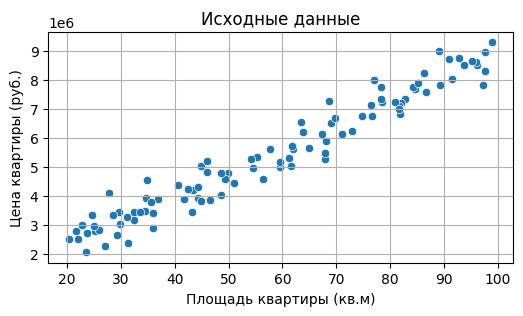

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 3))
sns.scatterplot(x=X, y=y)
plt.xlabel("Площадь квартиры (кв.м)")
plt.ylabel("Цена квартиры (руб.)")
plt.title("Исходные данные")
plt.grid(True)
plt.show()

`matplotlib.pyplot` и `seaborn` — популярные библиотеки для визуализации.

`plt.figure(figsize=(w, h))` — задаёт размер графика.

`sns.scatterplot()` — рисует точки на плоскости.

`plt.xlabel(), plt.ylabel(), plt.title()` — подписывают оси и заголовок графика.

`plt.grid()` — включает сетку для удобства.

## Нахождение весов методом наименьших квадратов (через линейную алгебру)

Метод наименьших квадратов позволяет найти такие коэффициенты линейной модели, при которых сумма квадратов ошибок между фактическими и предсказанными значениями будет минимальна. Для этого мы воспользуемся формулой:

$w = (X^TX)^{-1} X^Ty$

Перед этим преобразуем X в матрицу с единичным столбцом для свободного члена.

In [32]:
# Добавляем столбец единиц к X (для свободного члена)
X_design = np.vstack([np.ones_like(X), X]).T

print(X, '\n')
print(X_design)

# Решаем уравнение нормальных уравнений: theta = (X^T X)^(-1) X^T y
theta = X_design.T @ y
theta = np.linalg.inv(X_design.T @ X_design) @ theta

# Извлекаем коэффициенты
w0, w1 = theta

print(f"Оценённые параметры (ручной МНК):")
print(f"Свободный член (w0): {w0:,.2f}")
print(f"Коэффициент при площади (w1): {w1:,.2f}")

[49.96320951 96.05714451 78.55951534 67.89267874 32.48149124 32.47956163
 24.64668897 89.29409166 68.08920094 76.64580622 21.64675954 97.59278817
 86.59541126 36.98712885 34.54599738 34.67236079 44.33937944 61.98051453
 54.55560149 43.29833122 68.94823158 31.15950885 43.37157188 49.30894746
 56.48559874 82.81407691 35.97390257 61.13875507 67.39316551 23.71603302
 68.60358815 33.64192989 25.20412744 95.91084298 97.25056265 84.67178785
 44.36910153 27.81376912 74.73864212 55.2121995  29.76305879 59.61415281
 22.75108169 92.74563217 40.70239853 73.00178275 44.93688609 61.60544169
 63.73682235 34.78835644 97.56677022 82.01062587 95.15991533 91.58618803
 67.8319983  93.7499388  27.07940016 35.67862899 23.61818311 46.02642646
 51.09418318 41.70792254 86.29900073 48.54026614 42.47476077 63.41568665
 31.273938   84.17575846 25.96405149 98.95095493 81.77958154 35.89725452
 20.44176937 85.23691428 76.54858751 78.32057344 81.70162773 25.92357214
 48.67725828 29.26952476 89.04827407 69.86385015 46

`np.vstack([...]).T` — создаёт матрицу признаков с единичным столбцом (для w0).

`@ `— оператор матричного умножения.

`np.linalg.inv()` — возвращает обратную матрицу.

`.T` — транспонирование матрицы.

## Визуализация линии регрессии (ручной МНК)

Используя найденные коэффициенты, построим прямую линии регрессии на том же графике, где находятся исходные данные. Это позволит визуально оценить качество аппроксимации.

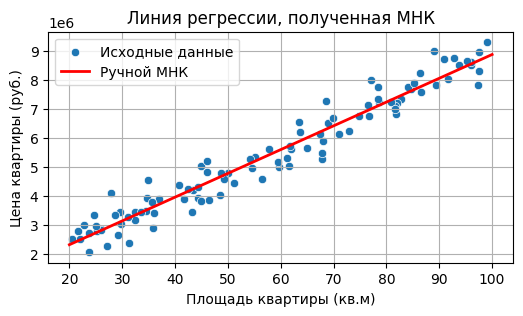

In [33]:
# Строим линию по уравнению y = w1 * x + w0
x_line = np.linspace(20, 100, 100)
y_line = w0 + w1 * x_line

plt.figure(figsize=(6, 3))
sns.scatterplot(x=X, y=y, label='Исходные данные')
plt.plot(x_line, y_line, color='red', label='Ручной МНК', linewidth=2)
plt.xlabel("Площадь квартиры (кв.м)")
plt.ylabel("Цена квартиры (руб.)")
plt.title("Линия регрессии, полученная МНК")
plt.legend()
plt.grid(True)
plt.show()

`np.linspace(start, stop, num)` — создаёт равномерно распределённые значения (для отрисовки линии).

`plt.plot()` — рисует линию на графике.

## Нахождение весов через готовую реализацию из sklearn

Теперь применим готовую модель линейной регрессии из библиотеки scikit-learn. Она позволяет быстро обучать модели без ручных вычислений.

In [34]:
from sklearn.linear_model import LinearRegression

# sklearn требует 2D вход — преобразуем X
X_2d = X.reshape(-1, 1)

print(X_2d)

# Обучаем модель
model = LinearRegression()
model.fit(X_2d, y)

# Получаем параметры
print("Параметры, найденные через sklearn:")
print(f"Свободный член (intercept_): {model.intercept_:,.2f}")
print(f"Коэффициент (coef_): {model.coef_[0]:,.2f}")

[[49.96320951]
 [96.05714451]
 [78.55951534]
 [67.89267874]
 [32.48149124]
 [32.47956163]
 [24.64668897]
 [89.29409166]
 [68.08920094]
 [76.64580622]
 [21.64675954]
 [97.59278817]
 [86.59541126]
 [36.98712885]
 [34.54599738]
 [34.67236079]
 [44.33937944]
 [61.98051453]
 [54.55560149]
 [43.29833122]
 [68.94823158]
 [31.15950885]
 [43.37157188]
 [49.30894746]
 [56.48559874]
 [82.81407691]
 [35.97390257]
 [61.13875507]
 [67.39316551]
 [23.71603302]
 [68.60358815]
 [33.64192989]
 [25.20412744]
 [95.91084298]
 [97.25056265]
 [84.67178785]
 [44.36910153]
 [27.81376912]
 [74.73864212]
 [55.2121995 ]
 [29.76305879]
 [59.61415281]
 [22.75108169]
 [92.74563217]
 [40.70239853]
 [73.00178275]
 [44.93688609]
 [61.60544169]
 [63.73682235]
 [34.78835644]
 [97.56677022]
 [82.01062587]
 [95.15991533]
 [91.58618803]
 [67.8319983 ]
 [93.7499388 ]
 [27.07940016]
 [35.67862899]
 [23.61818311]
 [46.02642646]
 [51.09418318]
 [41.70792254]
 [86.29900073]
 [48.54026614]
 [42.47476077]
 [63.41568665]
 [31.27393

`LinearRegression()` — создаёт модель линейной регрессии.

`model.fit(X, y)` — обучает модель.

`model.intercept_` — свободный член w0.

`model.coef_` — массив с коэффициентами признаков (в нашем случае — один коэффициент w1).

`reshape(-1, 1)` — преобразует одномерный массив в двумерный, как требует sklearn.

## Сравнение и визуализация результатов

Наконец, сравним линии регрессии, построенные вручную и при помощи sklearn. Выведем их на один график вместе с исходными данными. Результаты должны быть практически идентичны.

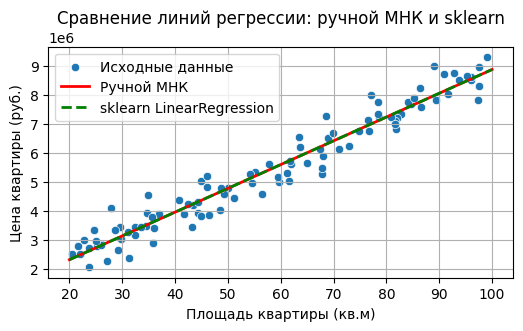

In [35]:
# Предсказания модели sklearn на том же диапазоне
y_sklearn = model.predict(x_line.reshape(-1, 1))

plt.figure(figsize=(6, 3))
sns.scatterplot(x=X, y=y, label='Исходные данные')
plt.plot(x_line, y_line, color='red', label='Ручной МНК', linewidth=2)
plt.plot(x_line, y_sklearn, color='green', linestyle='--', label='sklearn LinearRegression', linewidth=2)
plt.xlabel("Площадь квартиры (кв.м)")
plt.ylabel("Цена квартиры (руб.)")
plt.title("Сравнение линий регрессии: ручной МНК и sklearn")
plt.legend()
plt.grid(True)
plt.show()

`model.predict(X)` — предсказывает значения по входным данным.

`plt.plot(..., linestyle='--')` — пунктирная линия для различия.

## (Дополнительно) Визуализация примера про рост родителей и детей

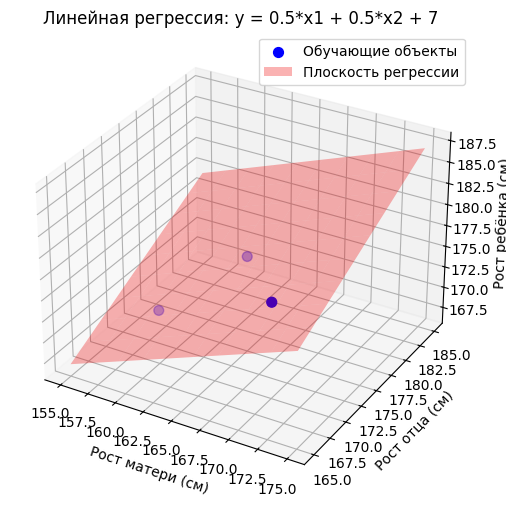

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Данные: рост матери (x1), рост отца (x2)
x1 = np.array([160, 165, 170])
x2 = np.array([170, 175, 170])

# Целевая переменная: рост ребёнка
y = 0.5 * x1 + 0.5 * x2 + 7

# Создание сетки для плоскости регрессии
x1_grid, x2_grid = np.meshgrid(np.linspace(155, 175, 10),
                               np.linspace(165, 185, 10))
y_grid = 0.5 * x1_grid + 0.5 * x2_grid + 7

# Построение графика
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Точки обучающей выборки
ax.scatter(x1, x2, y, color='blue', s=50, label='Обучающие объекты')

# Плоскость регрессии
ax.plot_surface(x1_grid, x2_grid, y_grid, color='red', alpha=0.3, label='Плоскость регрессии')

ax.set_xlabel('Рост матери (см)')
ax.set_ylabel('Рост отца (см)')
ax.set_zlabel('Рост ребёнка (см)')
ax.set_title('Линейная регрессия: y = 0.5*x1 + 0.5*x2 + 7')
plt.legend()
plt.show()
